# Análisis Exploratorio de Datos (EDA)
## Mercado Inmobiliario — Airbnb Price Prediction

**Dataset:** [Airbnb Price Prediction (Kaggle)](https://www.kaggle.com/datasets/stevezhenghp/airbnb-price-prediction)

---

### Objetivo
Realizar un análisis exploratorio profundo para comprender las características fundamentales, tendencias y patrones de los datos del mercado inmobiliario de Airbnb, como base para un modelo predictivo de precios.

## 1. Importación de Librerías y Carga de Datos

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
df = pd.read_csv("data/airbnb.csv")

print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 74,111 filas × 29 columnas


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.01,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.00,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.70,-73.99,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.00,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.00,1.00
1,6304928,5.13,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.00,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.77,-73.99,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.00,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.00,3.00
2,7919400,4.98,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.00,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.81,-73.94,The Garden Oasis,Harlem,10,92.00,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.00,3.00
3,13418779,6.62,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.00,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.77,-122.43,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.00,2.00
4,3808709,4.74,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.00,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.93,-77.03,Great studio in midtown DC,Columbia Heights,4,40.00,NaN,20009,0.00,1.00


In [3]:
print("=== Tipos de datos ===")
print(df.dtypes)

print(f"\n=== Valores nulos por columna ===")
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({"Nulos": nulls, "Porcentaje (%)": nulls_pct})

print(null_df[null_df["Nulos"] > 0].sort_values("Porcentaje (%)", ascending=False))

=== Tipos de datos ===
id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url                 str
zipcode                       str
bedrooms                  float64
beds                     

## 2. Preprocesamiento Básico

Antes del EDA se realizan ajustes mínimos necesarios:
- Convertir `log_price` a precio real (`price`)
- Convertir columnas booleanas codificadas como texto
- Extraer el año de `host_since`

In [4]:
# log_price → price real
df["price"] = np.expm1(df["log_price"])

# Booleanos de texto a numérico
bool_cols = ["host_has_profile_pic", "host_identity_verified",
             "instant_bookable", "cleaning_fee"]
for col in bool_cols:
    if col in df.columns:
        if df[col].dtype == "str":
            df[col] = df[col].map({"t": 1, "f": 0})
            continue
        if df[col].dtype == "bool":
            df[col] = df[col].map({True: 1, False: 0})
            continue

# host_since → años de experiencia
if "host_since" in df.columns:
    df["host_since"] = pd.to_datetime(df["host_since"], errors="coerce")
    df["host_years"] = 2024 - df["host_since"].dt.year

# host_response_rate → numérico
if "host_response_rate" in df.columns:
    df["host_response_rate"] = (
        df["host_response_rate"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

print("Preprocesamiento completado")
df[["log_price", "price"]].describe()

Preprocesamiento completado


,log_price,price
count,74111.00,74111.00
mean,4.78,159.37
std,0.72,168.58
min,0.00,0.00
25%,4.32,74.00
50%,4.71,110.00
75%,5.22,184.00
max,7.60,1998.00


## 3. Análisis Descriptivo

### 3.1 Estadísticas generales de variables numéricas

In [5]:
df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
id,74111.00,11266617.10,6081734.89,344.00,6261964.50,12254147.00,16402260.50,21230903.00
log_price,74111.00,4.78,0.72,0.00,4.32,4.71,5.22,7.60
accommodates,74111.00,3.16,2.15,1.00,2.00,2.00,4.00,16.00
bathrooms,73911.00,1.24,0.58,0.00,1.00,1.00,1.00,8.00
cleaning_fee,74111.00,0.73,0.44,0.00,0.00,1.00,1.00,1.00
host_has_profile_pic,73923.00,1.00,0.06,0.00,1.00,1.00,1.00,1.00
host_identity_verified,73923.00,0.67,0.47,0.00,0.00,1.00,1.00,1.00
host_response_rate,55812.00,94.35,16.34,0.00,100.00,100.00,100.00,100.00
instant_bookable,74111.00,0.26,0.44,0.00,0.00,0.00,1.00,1.00
latitude,74111.00,38.45,3.08,33.34,34.13,40.66,40.75,42.39


### 3.2 Identificación de variables clave para el precio

Se calcula la correlación de todas las variables numéricas con `log_price`
para identificar cuáles tienen mayor poder predictivo.

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_price = (
    df[num_cols]
    .corr()["log_price"]
    .drop(["log_price", "price"])
    .sort_values(key=abs, ascending=False)
)

print("=== Correlación con log_price (Top 15) ===")
print(corr_price.head(15).to_string())

=== Correlación con log_price (Top 15) ===
accommodates              0.57
bedrooms                  0.47
beds                      0.44
bathrooms                 0.36
cleaning_fee              0.11
review_scores_rating      0.09
host_years                0.08
longitude                -0.05
instant_bookable         -0.04
number_of_reviews        -0.03
host_identity_verified    0.02
host_has_profile_pic     -0.01
id                       -0.01
host_response_rate       -0.01
latitude                 -0.00


## 4. Visualizaciones

### 4.1 Distribución del Precio (variable objetivo)

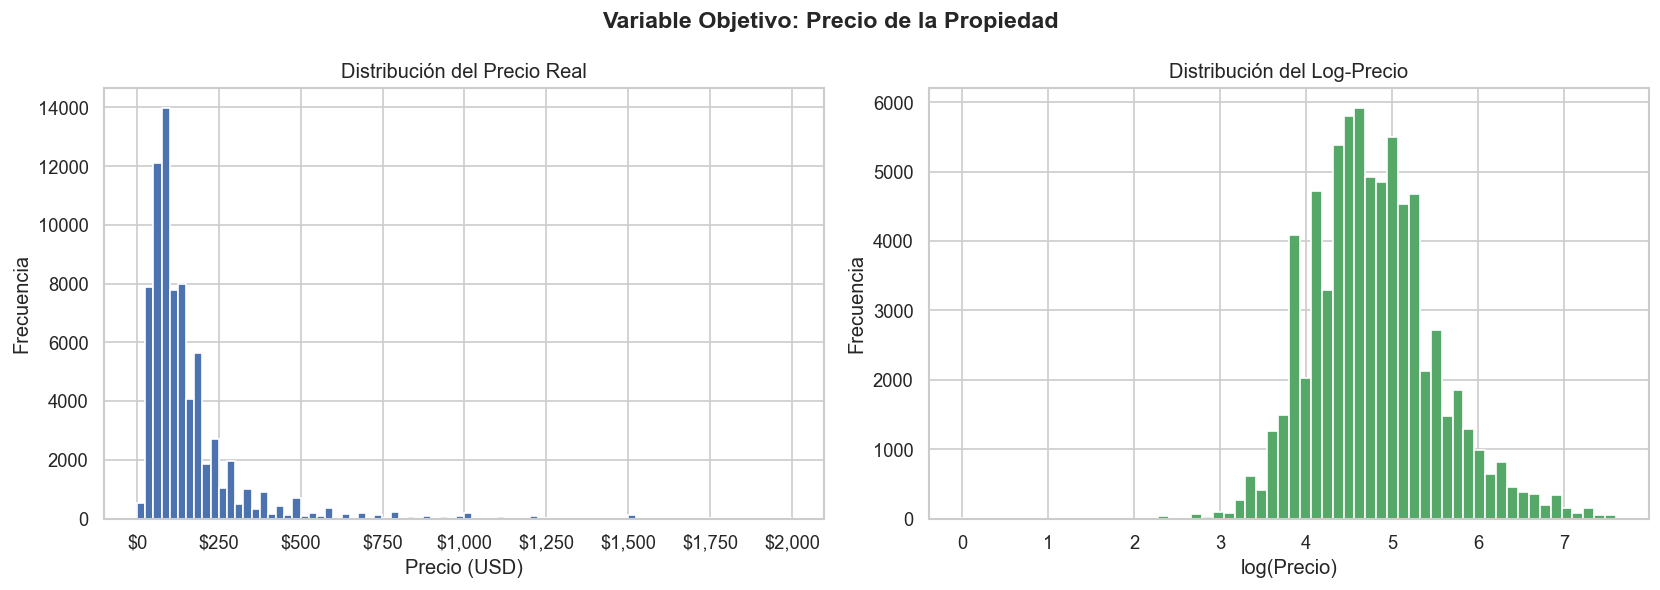

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio real (con sesgo)
axes[0].hist(df["price"].dropna(), bins=80, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribución del Precio Real")
axes[0].set_xlabel("Precio (USD)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Log-precio (normalizado)
axes[1].hist(df["log_price"].dropna(), bins=60, color="#55A868", edgecolor="white")
axes[1].set_title("Distribución del Log-Precio")
axes[1].set_xlabel("log(Precio)")
axes[1].set_ylabel("Frecuencia")

plt.suptitle("Variable Objetivo: Precio de la Propiedad", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/hist_precio.png", bbox_inches="tight")
plt.show()

### Interpretación — Distribución del Precio

- El **precio real** muestra una distribución con la mayoría de las propiedades concentradas en rangos económicos y una cola larga de propiedades de lujo con precios extremos.
- La transformación **log-precio** corrige este sesgo y produce una distribución aproximadamente normal (forma de campana), lo que la convierte en la variable idónea para modelado predictivo.
- La media y la mediana del precio real difieren significativamente, confirmando la presencia de valores atípicos en el extremo superior.

### 4.2 Histogramas de Variables Numéricas Clave

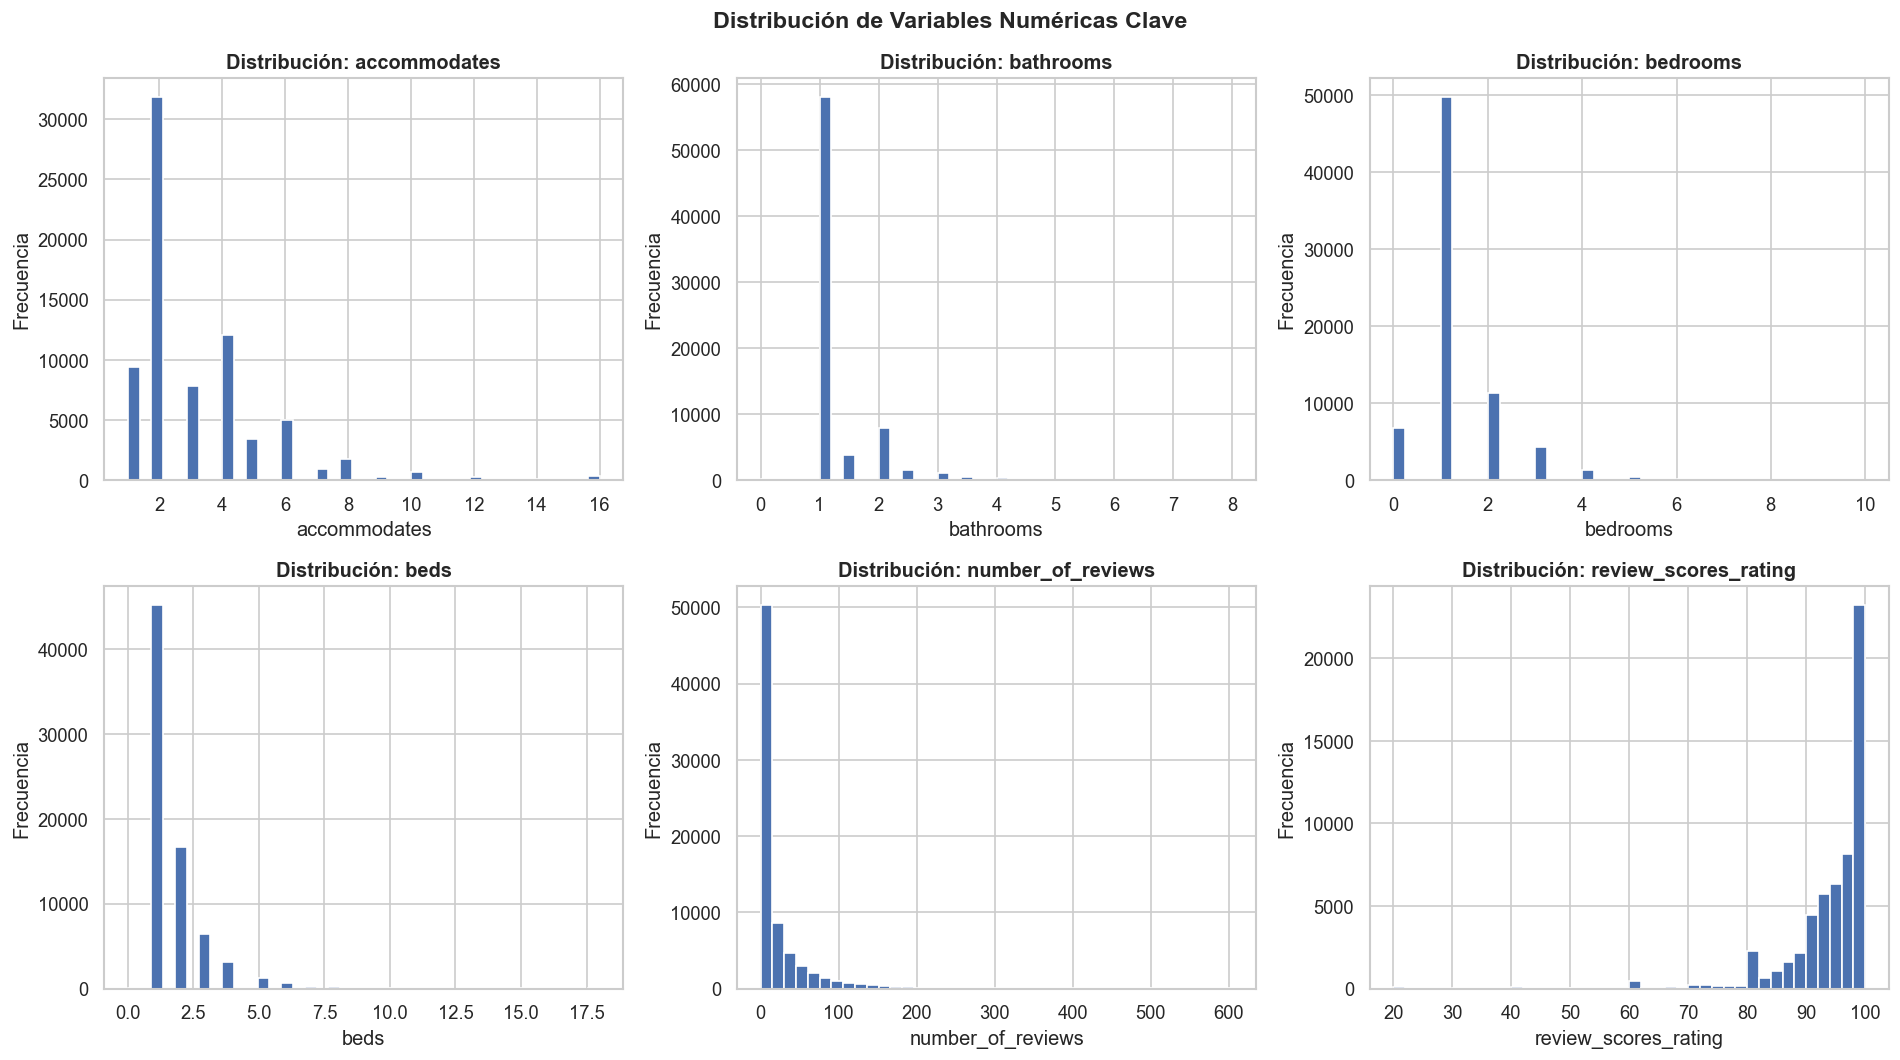

In [8]:
key_vars = ["accommodates", "bathrooms", "bedrooms", "beds",
            "number_of_reviews", "review_scores_rating"]
key_vars = [c for c in key_vars if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    axes[i].hist(df[col].dropna(), bins=40, color="#4C72B0", edgecolor="white")
    axes[i].set_title(f"Distribución: {col}", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

for j in range(len(key_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Variables Numéricas Clave", fontsize=14,
             fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/hist_variables_clave.png", bbox_inches="tight")
plt.show()

### Interpretación — Histogramas de Variables Clave

- **accommodates / bedrooms / beds / bathrooms:** La mayoría de las propiedades tienen capacidad para 2–4 personas y 1–2 habitaciones, valores altos son infrecuentes y representan propiedades de gran tamaño.
- **number_of_reviews:** Distribución muy sesgada, muchas propiedades tienen pocas reseñas, mientras que unas pocas acumulan cientos.
- **review_scores_rating:** Concentración marcada en puntuaciones altas (90–100), lo que indica que la plataforma tiende a mostrar alojamientos bien evaluados o que los anfitriones con bajas calificaciones abandonan la plataforma.

### 4.3 Box Plots — Precio por Tipo de Habitación y Ciudad

/var/folders/jj/kshx6fns0jd2nbcfpl0qvn4w0000gn/T/ipykernel_23902/3533447582.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="room_type", y="log_price", order=order, palette="Set2", ax=axes[0])
/var/folders/jj/kshx6fns0jd2nbcfpl0qvn4w0000gn/T/ipykernel_23902/3533447582.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="city", y="log_price", order=order_city, palette="Set3", ax=axes[1])


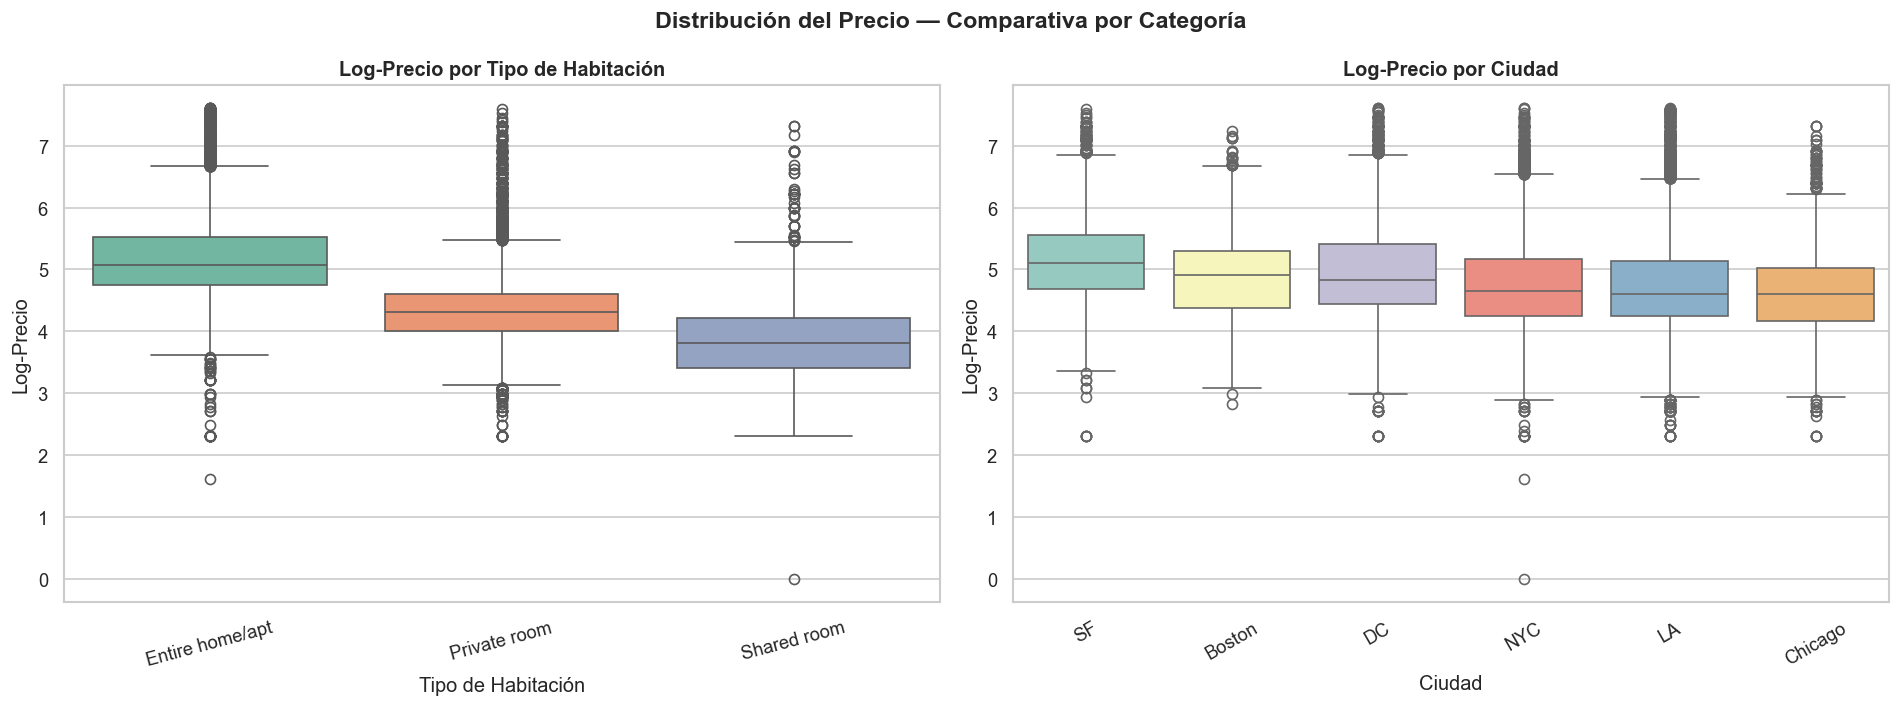

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por tipo de habitación
if "room_type" in df.columns:
    order = df.groupby("room_type")["log_price"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x="room_type", y="log_price", order=order, palette="Set2", ax=axes[0])
    axes[0].set_title("Log-Precio por Tipo de Habitación", fontweight="bold")
    axes[0].set_xlabel("Tipo de Habitación")
    axes[0].set_ylabel("Log-Precio")
    axes[0].tick_params(axis="x", rotation=15)

# Por ciudad
if "city" in df.columns:
    order_city = (df.groupby("city")["log_price"].median()
                    .sort_values(ascending=False).index)
    sns.boxplot(data=df, x="city", y="log_price", order=order_city, palette="Set3", ax=axes[1])
    axes[1].set_title("Log-Precio por Ciudad", fontweight="bold")
    axes[1].set_xlabel("Ciudad")
    axes[1].set_ylabel("Log-Precio")
    axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Distribución del Precio — Comparativa por Categoría",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/boxplot_precio.png", bbox_inches="tight")
plt.show()

### Interpretación — Box Plots

**Por Tipo de Habitación:**
- **"Entire home/apt"** presentan los precios más altos y mayor variabilidad, lo que tiene sentido al ofrecer privacidad total.
- **"Private room"** se posiciona en un rango intermedio, siendo la opción más frecuente en el dataset.
- **"Shared room"** es la opción más económica con menor dispersión.
- Los tres tipos muestran **outliers** superiores, reflejando propiedades de lujo dentro de cada categoría.

**Por Ciudad:**
- Ciudades como **San Francisco** y **NYC** concentran los precios más elevados, consistente con su alto costo de vida.
- Se observa que incluso dentro de la misma ciudad la dispersión es alta, indicando que el tipo de propiedad y ubicación específica son factores determinantes.

### 4.4 Box Plots — Detección de Outliers en Variables Continuas

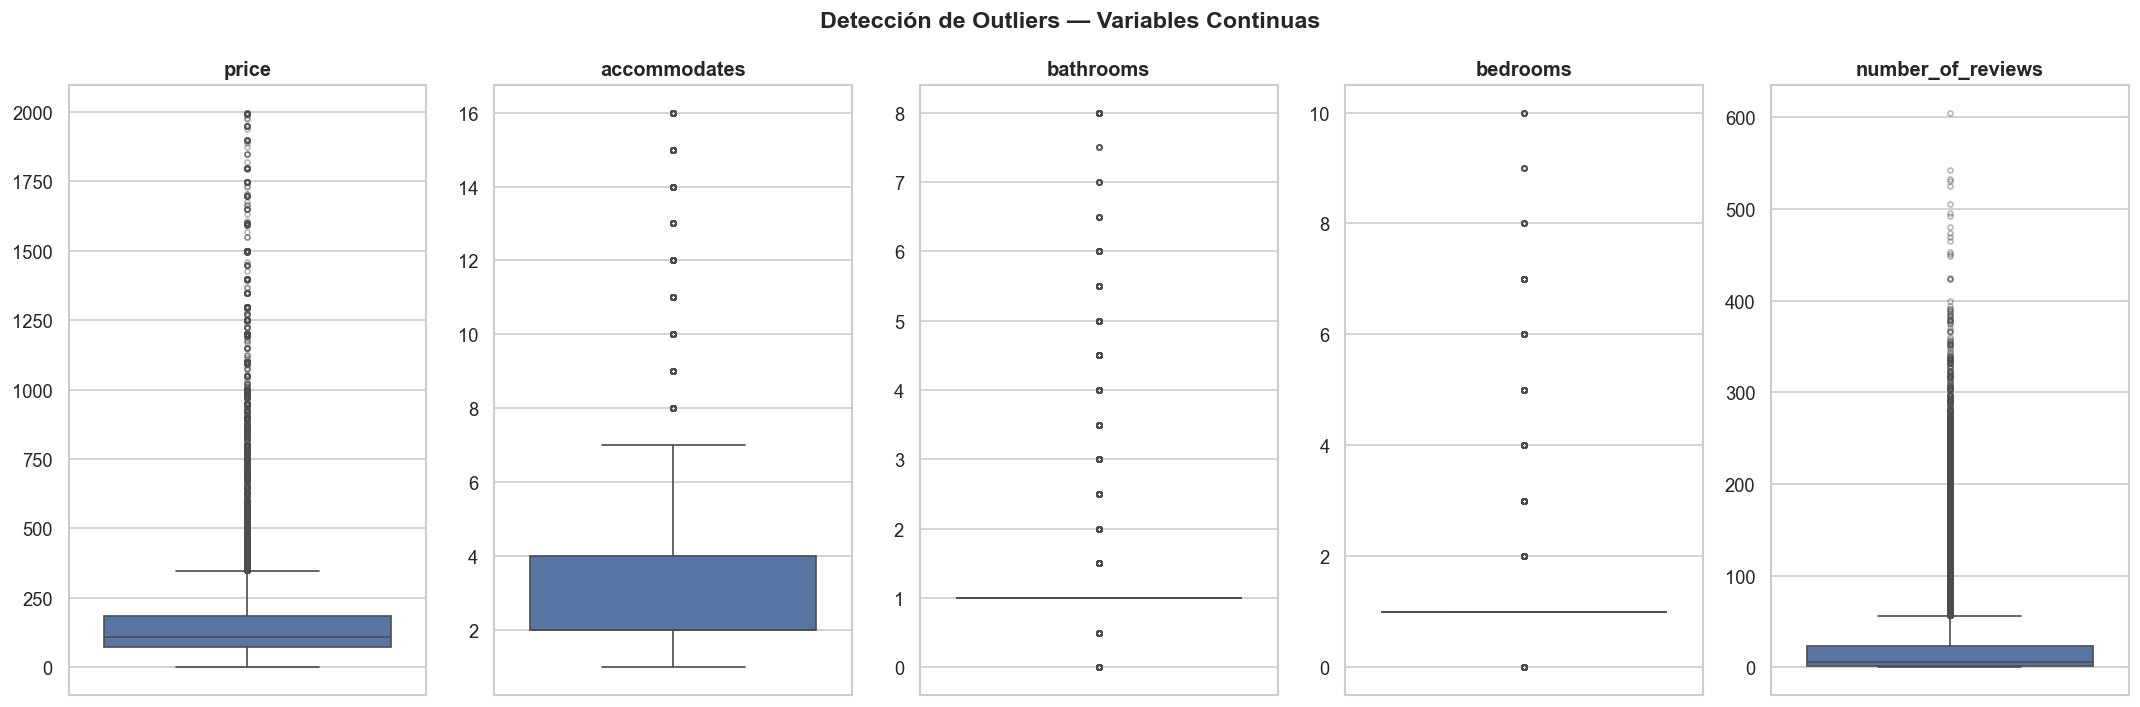

In [10]:
outlier_vars = ["price", "accommodates", "bathrooms",
                "bedrooms", "number_of_reviews"]
outlier_vars = [c for c in outlier_vars if c in df.columns]

fig, axes = plt.subplots(1, len(outlier_vars), figsize=(18, 6))

for i, col in enumerate(outlier_vars):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color="#4C72B0",
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("")

plt.suptitle("Detección de Outliers — Variables Continuas",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/boxplot_outliers.png", bbox_inches="tight")
plt.show()

### Interpretación — Outliers

- **price:** Presencia de outliers extremos (propiedades de más de $1,000/noche), representando propiedades de lujo que podrían distorsionar los modelos si no se tratan.
- **accommodates / bedrooms / bathrooms:** Outliers superiores correspondientes a grandes mansiones o propiedades comerciales. Deben analizarse si son registros legítimos o errores de captura.
- **number_of_reviews:** Distribución muy sesgada, pocas propiedades acumulan cientos de reseñas, posiblemente anfitriones profesionales con múltiples años en la plataforma.

### 4.5 Scatter Plots — Relación entre Variables y el Precio

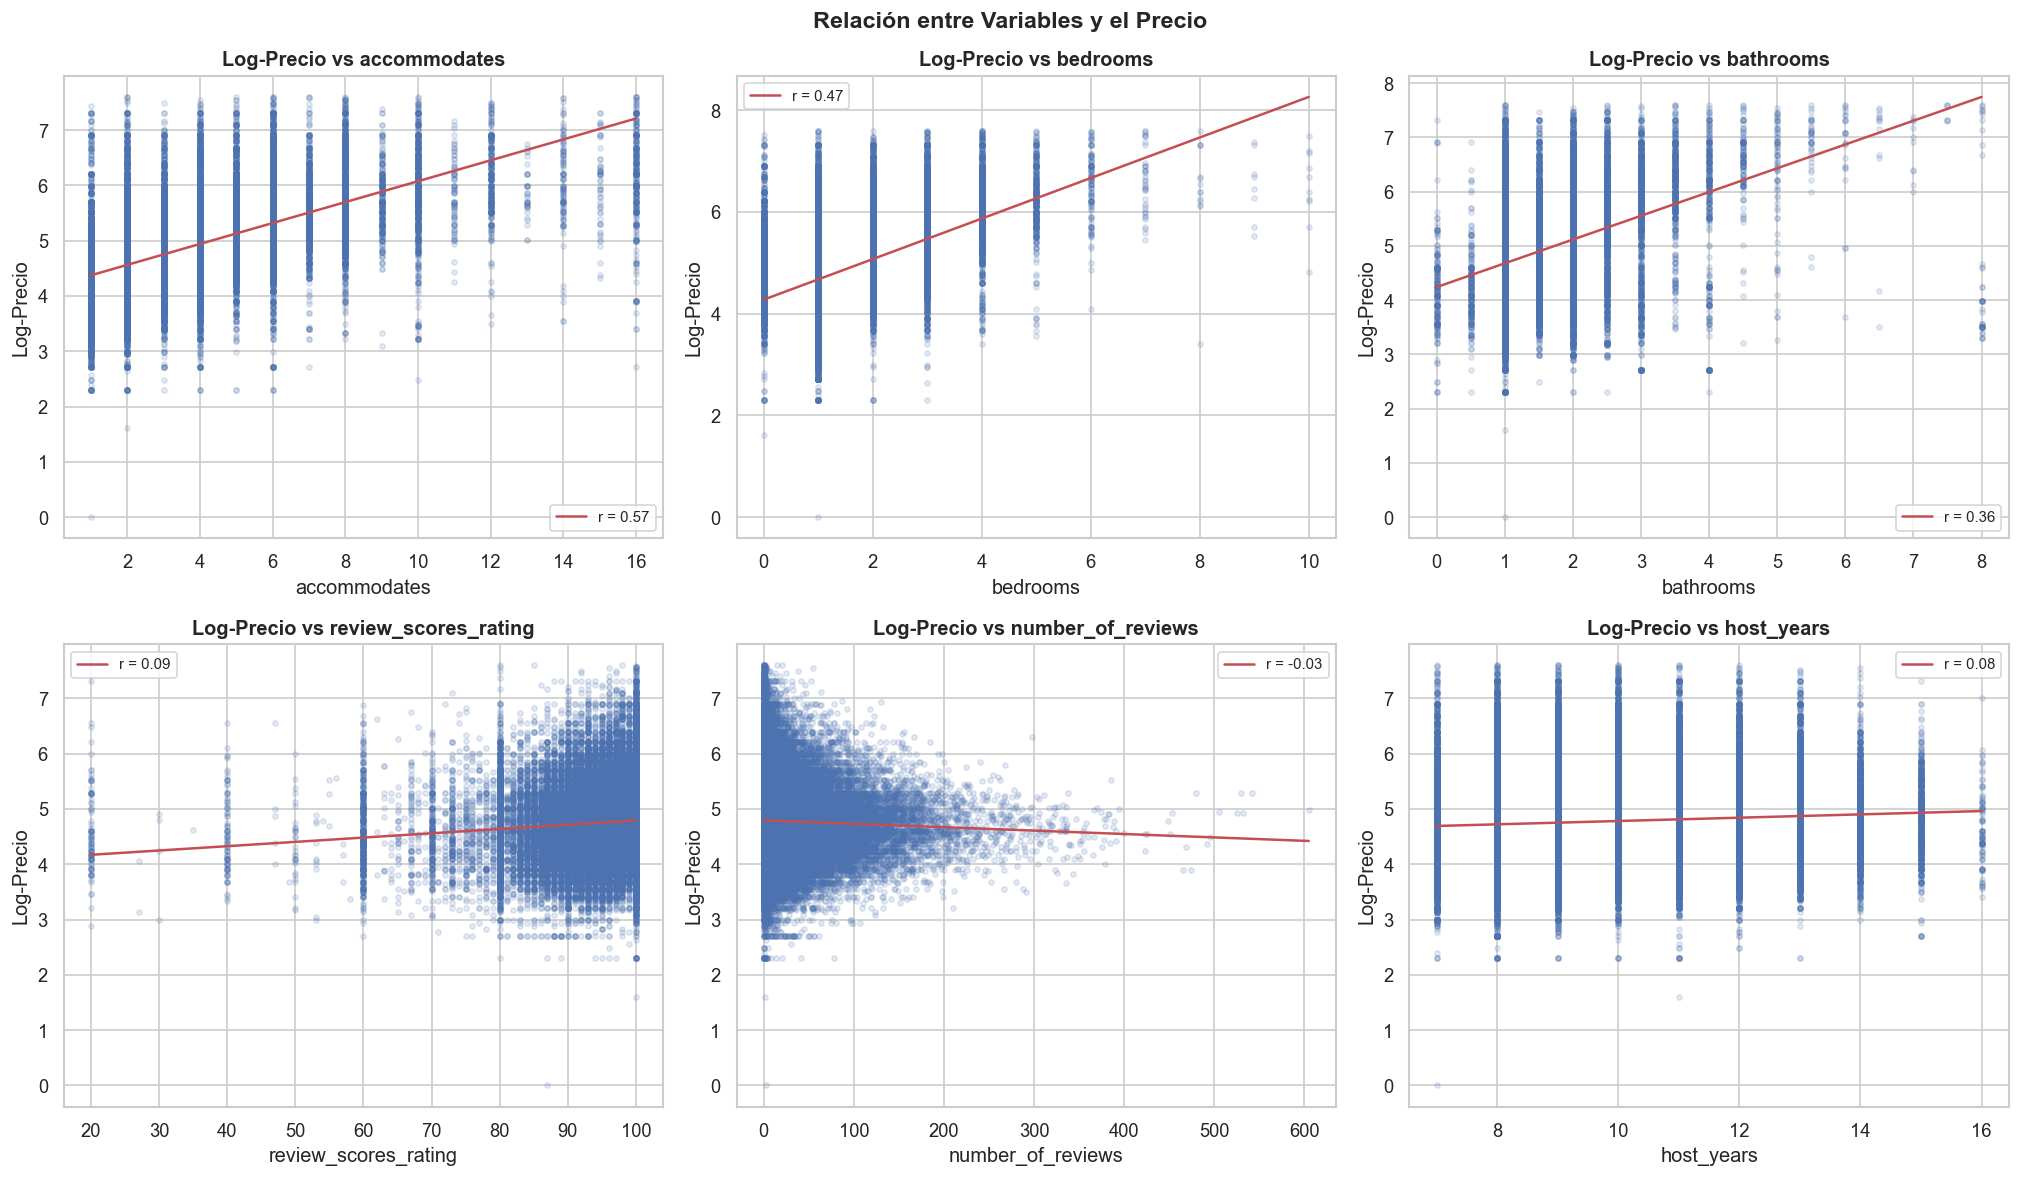

In [11]:
scatter_vars = ["accommodates", "bedrooms", "bathrooms",
                "review_scores_rating", "number_of_reviews", "host_years"]
scatter_vars = [c for c in scatter_vars if c in df.columns]

n = len(scatter_vars)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(17, rows * 5))
axes = axes.flatten()

for i, col in enumerate(scatter_vars):
    temp = df[[col, "log_price"]].dropna()
    axes[i].scatter(temp[col], temp["log_price"], alpha=0.15,
                    s=10, color="#4C72B0")
    # Línea de tendencia
    m, b = np.polyfit(temp[col], temp["log_price"], 1)
    x_line = np.linspace(temp[col].min(), temp[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="#C44E52", linewidth=1.5,
                 label=f"r = {temp.corr().iloc[0,1]:.2f}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Log-Precio")
    axes[i].set_title(f"Log-Precio vs {col}", fontweight="bold")
    axes[i].legend(fontsize=9)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Relación entre Variables y el Precio", fontsize=14,
             fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/scatter_precio.png", bbox_inches="tight")
plt.show()

### Interpretación — Scatter Plots

- **accommodates** y **bedrooms:** Muestran la correlación positiva más fuerte con el precio (a mayor capacidad, mayor precio).
- **bathrooms:** Correlación positiva moderada-alta, propiedades con más baños tienden a ser más grandes y costosas.
- **review_scores_rating:** Correlación débil pero positiva, calificaciones más altas se asocian ligeramente con precios mayores, posiblemente porque propiedades premium atraen más cuidado del anfitrión.
- **number_of_reviews:** Correlación negativa débil, propiedades más baratas tienen más reseñas (mayor rotación de huéspedes).
- **host_years:** Correlación positiva moderada, anfitriones con más experiencia pueden cobrar tarifas premium por su reputación acumulada.

### 4.6 Mapa de Calor de Correlaciones

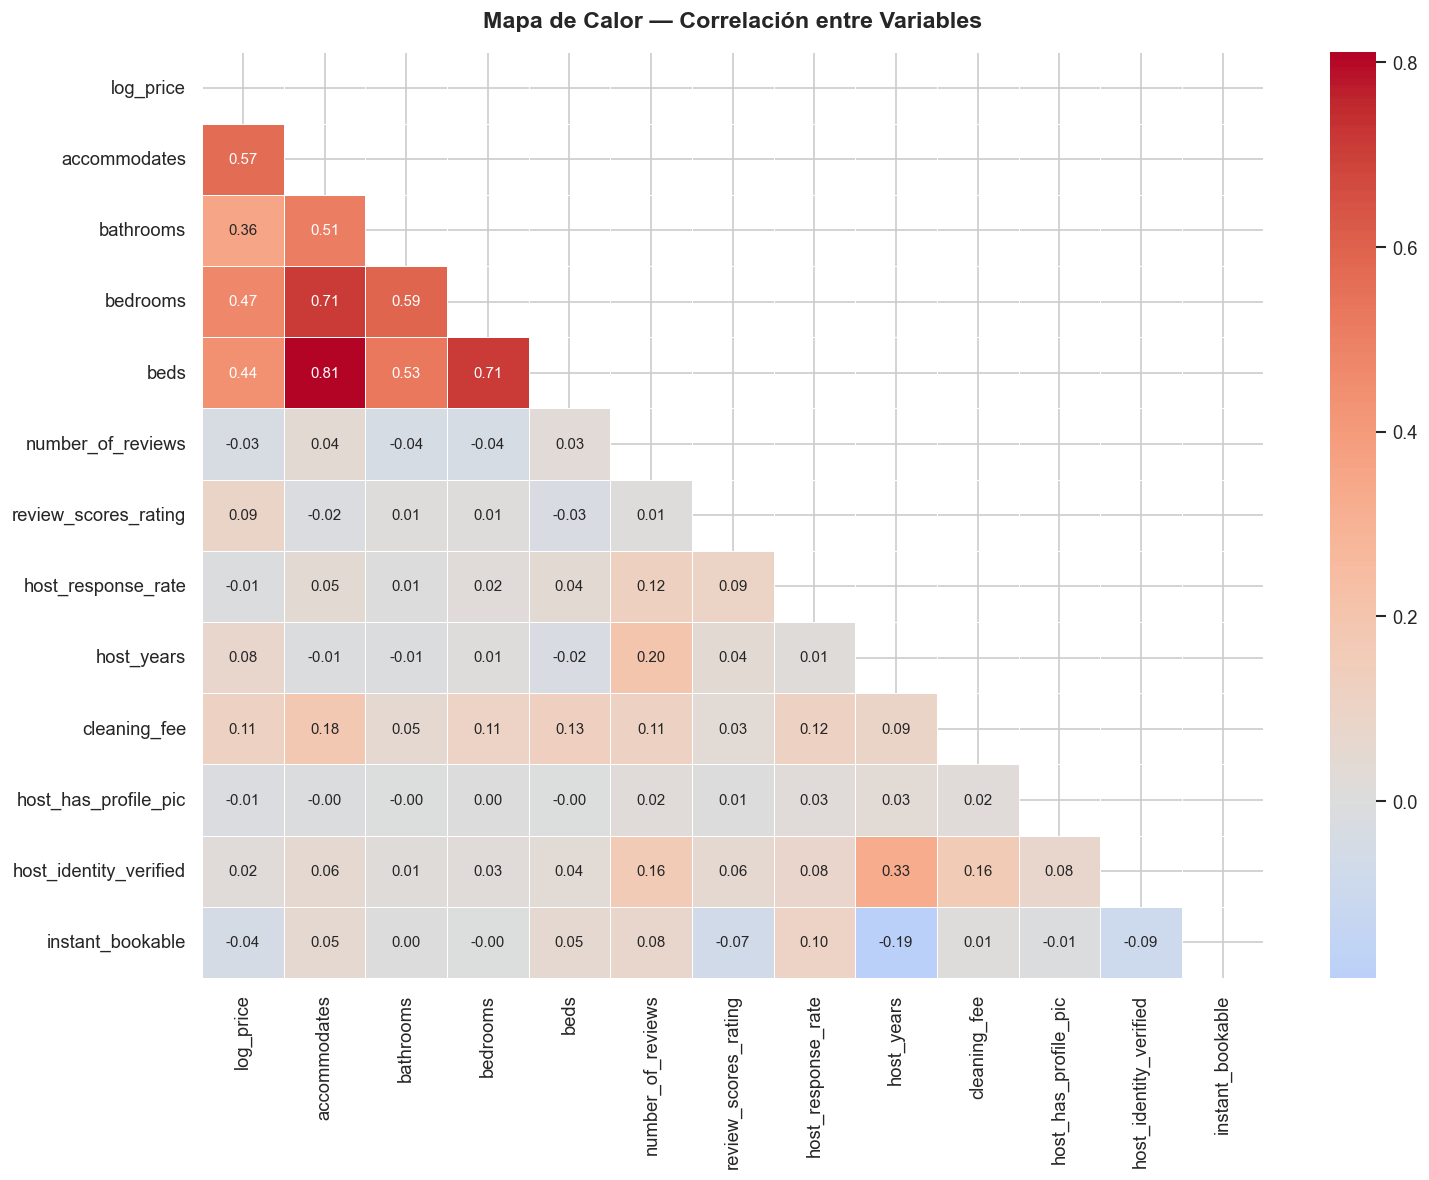

In [12]:
corr_cols = [c for c in [
    "log_price", "accommodates", "bathrooms", "bedrooms", "beds",
    "number_of_reviews", "review_scores_rating", "host_response_rate",
    "host_years", "cleaning_fee", "host_has_profile_pic",
    "host_identity_verified", "instant_bookable"
] if c in df.columns]

corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Mapa de Calor — Correlación entre Variables",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("visualizations/heatmap_correlaciones.png", bbox_inches="tight")
plt.show()

### Interpretación — Mapa de Calor de Correlaciones

**Correlaciones más fuertes con `log_price`:**

| Variable | Correlación | Dirección |
| --- | --- | --- |
| `accommodates` | Alta | Positiva |
| `bedrooms` | Alta | Positiva |
| `bathrooms` | Alta | Positiva |
| `beds` | Moderada | Positiva |
| `cleaning_fee` | Moderada | Positiva |
| `number_of_reviews` | Baja-negativa | Negativa |

**Multicolinealidad detectada:**
- `accommodates`, `bedrooms`, `beds` y `bathrooms` están altamente correlacionadas entre sí (r > 0.7). En la fase de modelado será necesario considerar técnicas para manejar la multicolinealidad (PCA, selección de características o regularización).

**Variables menos relevantes:**
- `host_has_profile_pic`, `instant_bookable` y `host_identity_verified` tienen correlaciones muy bajas con el precio; su aporte predictivo como variables individuales es limitado.

### 4.7 Análisis de Precio Promedio por Tipo de Propiedad

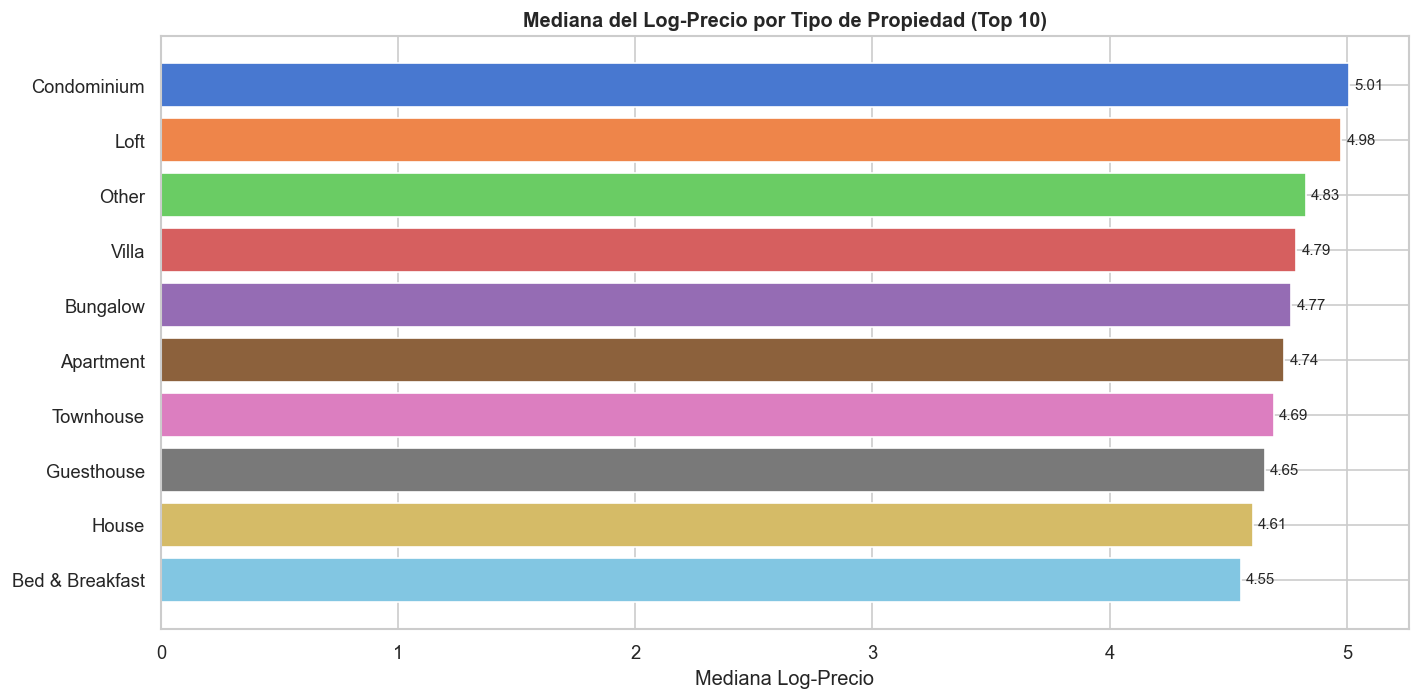

In [13]:
if "property_type" in df.columns:
    top_props = df["property_type"].value_counts().head(10).index
    df_top = df[df["property_type"].isin(top_props)]

    avg_price = (df_top.groupby("property_type")["log_price"]
                       .median()
                       .sort_values(ascending=False))

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(avg_price.index, avg_price.values,
                   color=sns.color_palette("muted", len(avg_price)))
    ax.set_xlabel("Mediana Log-Precio")
    ax.set_title("Mediana del Log-Precio por Tipo de Propiedad (Top 10)",
                 fontweight="bold")
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("visualizations/bar_property_type.png", bbox_inches="tight")
    plt.show()

### Interpretación — Precio por Tipo de Propiedad

- Las **villas**, **casas** y **apartamentos completos** encabezan el ranking
  de precios medianos, consistente con la mayor privacidad y espacio que ofrecen.
- Los **hostels** y **habitaciones compartidas** representan las opciones más
  económicas.


### 4.8 Distribución Geográfica del Precio (Latitud y Longitud)

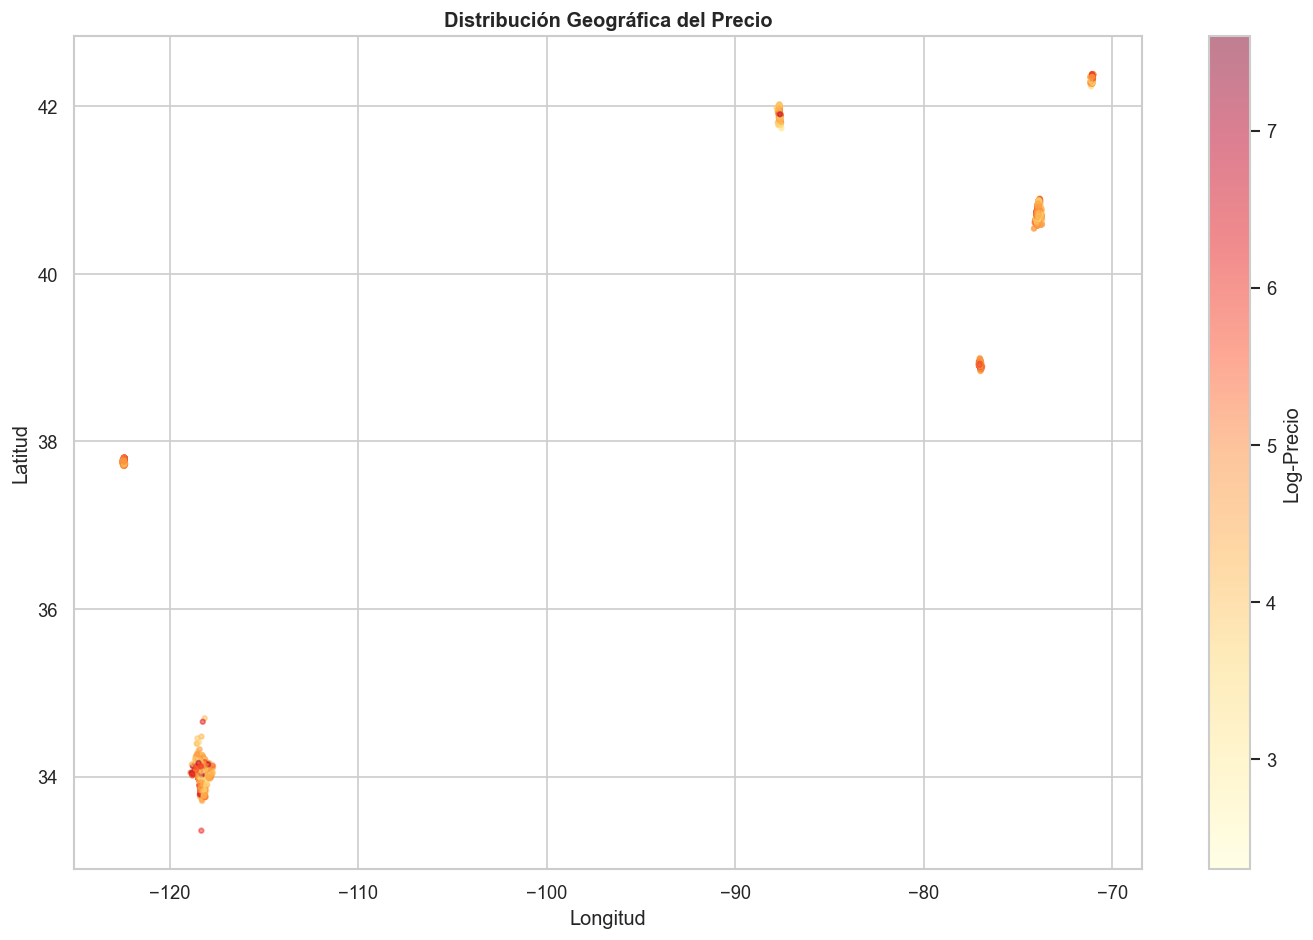

In [14]:
if "latitude" in df.columns and "longitude" in df.columns:
    sample = df[["latitude", "longitude", "log_price"]].dropna().sample(
        min(5000, len(df)), random_state=42
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    sc = ax.scatter(
        sample["longitude"], sample["latitude"],
        c=sample["log_price"], cmap="YlOrRd",
        alpha=0.5, s=8
    )
    plt.colorbar(sc, ax=ax, label="Log-Precio")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.set_title("Distribución Geográfica del Precio", fontweight="bold")
    plt.tight_layout()
    plt.savefig("visualizations/scatter_geo.png", bbox_inches="tight")
    plt.show()

### Interpretación — Distribución Geográfica

- Se identifican **clusters bien definidos** correspondientes a las distintas
  ciudades del dataset (NYC, SF, LA, Chicago, Boston, DC).
- Las zonas con precios más elevados (tonos rojos intensos) corresponden a
  **centros urbanos y zonas turísticas de alta demanda**.
- Las áreas periféricas tienden a mostrar precios más bajos, lo que sugiere
  que la **ubicación geográfica específica** es uno de los predictores más
  importantes del precio.
- Esta visualización refuerza la necesidad de incluir `latitude`, `longitude`
  y `city` como variables en el modelo.

## 5. Resumen de Hallazgos

### 5.1 Variables más influyentes en el precio

In [16]:
top_corr = corr_price.head(10).reset_index()
top_corr.columns = ["Variable", "Correlación con log_price"]
top_corr["Dirección"] = top_corr["Correlación con log_price"].apply(
    lambda x: "Positiva" if x > 0 else "Negativa"
)
top_corr["Correlación con log_price"] = top_corr[
    "Correlación con log_price"
].round(4)
top_corr

,Variable,Correlación con log_price,Dirección
0,accommodates,0.57,Positiva
1,bedrooms,0.47,Positiva
2,beds,0.44,Positiva
3,bathrooms,0.36,Positiva
4,cleaning_fee,0.11,Positiva
5,review_scores_rating,0.09,Positiva
6,host_years,0.08,Positiva
7,longitude,-0.05,Negativa
8,instant_bookable,-0.04,Negativa
9,number_of_reviews,-0.03,Negativa


## 6. Conclusiones del EDA

### Hallazgos principales

1. **Variable objetivo:** `log_price` sigue una distribución aproximadamente normal, lo que la hace adecuada para regresión lineal y otros modelos paramétricos.

2. **Variables de mayor impacto:** El tamaño de la propiedad —medido por `accommodates`, `bedrooms`, `bathrooms` y `beds`— es el conjunto de variables con mayor correlación con el precio. La ubicación (`city`, coordenadas) también es determinante.

3. **Multicolinealidad:** Las variables de tamaño están altamente correlacionadas entre sí. Se recomienda aplicar PCA o seleccionar solo una de ellas como representativa del tamaño.

4. **Outliers:** Existen propiedades con precios extremadamente altos que deben tratarse antes del modelado (Winsorización o filtrado al percentil 99).

5. **Variables categóricas:** `room_type`, `property_type` y `city` explican diferencias significativas en precio y deberán codificarse (One-Hot Encoding o Target Encoding) para el modelo.

6. **Calidad de datos:** Algunas columnas como `review_scores_rating` y `bathrooms` presentan valores nulos que deberán imputarse en la siguiente fase.